# 03 — Model Evaluation

**Deliverable 3** of the PPE Compliance Monitor capstone.

The model trained in notebook 04 produces numbers. This notebook decides **what those numbers
mean for a safety system**, and picks the thresholds the project actually ships with.

Three things happen here, in order:

1. **Measure** — `model.val()` on the *held-out test split*, which the model has never seen and
   which was not used for early stopping either.
2. **Interpret** — per-class metrics and the confusion matrix, read against the asymmetric cost
   of errors on a site.
3. **Decide** — sweep confidence and NMS IoU against ground truth and choose an operating point,
   with the reasoning written down.

### The asymmetry that drives every decision below

| | Cost |
|---|---|
| **False negative** on `NO-Hardhat` | A worker without a hard hat is waved through. This is the failure that kills people. |
| **False positive** on `NO-Hardhat` | A supervisor walks over and finds a compliant worker. Five seconds wasted. |

These are not remotely equal, so **F1 is the wrong thing to maximise** — it weights precision and
recall the same. The operating point below maximises recall on the violation classes subject to a
precision floor that keeps the system credible: a monitor that cries wolf constantly gets muted,
and a muted monitor turns every future true positive into a miss as well.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "ppe_monitor").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]

import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from ultralytics import YOLO, settings

settings.update({
    "runs_dir": str(ROOT / "runs"),
    "datasets_dir": str(ROOT / "data" / "datasets"),
})

from ppe_monitor import dataset
from ppe_monitor.dataset import CLASS_NAMES
from ppe_monitor.config import MODEL_DIR, OUTPUT_DIR, VIOLATION_CLASSES

pd.set_option("display.width", 160)


def show(img_bgr, max_w=820, title=None):
    h, w = img_bgr.shape[:2]
    if w > max_w:
        img_bgr = cv2.resize(img_bgr, (max_w, int(h * max_w / w)), interpolation=cv2.INTER_AREA)
    ok, buf = cv2.imencode(".jpg", img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 82])
    if title:
        print(title)
    display(IPyImage(data=buf.tobytes(), format="jpeg"))


WEIGHTS = MODEL_DIR / "best.pt"
assert WEIGHTS.exists(), (
    f"{WEIGHTS} not found. Run notebooks/04_training_colab.ipynb on a GPU and unpack "
    "ppe_training_artifacts/best.pt into models/."
)

model = YOLO(str(WEIGHTS))
print("weights :", WEIGHTS)
print("classes :", list(model.names.values()))

weights : C:\Users\ksama\OneDrive\المستندات\projects\OpenCode\ppe-compliance-monitor\models\best.pt
classes : ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


In [2]:
# Rebuild data.yaml locally - it carries absolute paths, so it cannot be shared
# between the Colab run and this machine.
root = dataset.download()
split_root = dataset.find_split_root(root)
splits = dataset.resolve_splits(split_root)
DATA_YAML = dataset.write_data_yaml(split_root, ROOT / "data" / "data.yaml", splits)

report = dataset.describe(splits)
print("held-out splits:")
for name in ("valid", "test"):
    stats = report[name]
    print(f"  {name:<6} {stats['images']:>4} images, {stats['instances']:>4} instances")

test_counts = report["test"]["per_class"]
print("\ntest-split instances per class:")
for cls, n in sorted(test_counts.items(), key=lambda kv: -kv[1]):
    flag = "  <-- violation class" if cls in VIOLATION_CLASSES else ""
    print(f"  {cls:<16}{n:>5}{flag}")

dataset root: C:\Users\ksama\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3


held-out splits:
  valid   114 images,  697 instances
  test     82 images,  760 instances

test-split instances per class:
  Person            174
  Hardhat           110
  Safety Cone        92
  NO-Safety Vest     90  <-- violation class
  NO-Mask            79  <-- violation class
  Safety Vest        61
  machinery          44
  NO-Hardhat         41  <-- violation class
  vehicle            41
  Mask               28


## 1. Headline metrics on the held-out test split

`split="test"` matters. The validation split steered early stopping and model selection during
training, so reporting on it flatters the model. The test split was used for neither.

In [3]:
metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    device="cpu",
    workers=0,
    project=str(ROOT / "runs" / "eval"),
    name="test",
    exist_ok=True,
    plots=True,
    verbose=False,
)

print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")
print(f"precision : {metrics.box.mp:.4f}")
print(f"recall    : {metrics.box.mr:.4f}")
print()
print("mAP50    - are the boxes roughly in the right place? (IoU > 0.50)")
print("mAP50-95 - are they tightly in the right place? (averaged over IoU 0.50:0.95)")
print("           This is the strict number, and the one worth quoting.")

VAL_DIR = Path(metrics.save_dir)
print(f"\nplots written to {VAL_DIR}")

Ultralytics 8.4.129  Python-3.11.15 torch-2.13.0+cpu CPU (Intel Core i7-10510U 1.80GHz)


YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 213.980.0 MB/s, size: 52.7 KB)


val: Scanning C:\Users\ksama\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data\test\labels.cache... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 16% ━━────────── 1/6 11.9s/it 3.6s<59.4s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.1s/it 18.8s

                   all         82        760      0.855      0.606       0.68      0.377


Speed: 4.2ms preprocess, 182.9ms inference, 0.0ms loss, 7.1ms postprocess per image


Results saved to C:\Users\ksama\OneDrive\\projects\OpenCode\ppe-compliance-monitor\runs\eval\test


mAP50     : 0.6798
mAP50-95  : 0.3771
precision : 0.8546
recall    : 0.6061

mAP50    - are the boxes roughly in the right place? (IoU > 0.50)
mAP50-95 - are they tightly in the right place? (averaged over IoU 0.50:0.95)
           This is the strict number, and the one worth quoting.

plots written to C:\Users\ksama\OneDrive\المستندات\projects\OpenCode\ppe-compliance-monitor\runs\eval\test


## 2. Per-class breakdown

A single mAP number is dominated by whichever class is most common — here `Person`, at nearly a
quarter of all instances. That average can look healthy while the class the system exists to
detect is failing.

In [4]:
rows = []
for i, cls_idx in enumerate(metrics.box.ap_class_index):
    name = CLASS_NAMES[int(cls_idx)]
    p, r, ap50, ap = metrics.box.class_result(i)
    rows.append({
        "class": name,
        "test_instances": test_counts.get(name, 0),
        "precision": round(float(p), 4),
        "recall": round(float(r), 4),
        "mAP50": round(float(ap50), 4),
        "mAP50-95": round(float(ap), 4),
        "violation_class": name in VIOLATION_CLASSES,
    })

per_class = pd.DataFrame(rows).sort_values("mAP50-95", ascending=False)
display(per_class)

print("\n--- the classes this system is judged on ---")
critical = per_class[per_class["violation_class"]]
display(critical)

print(f"mean recall, violation classes : {critical['recall'].mean():.4f}")
print(f"mean recall, all classes       : {per_class['recall'].mean():.4f}")

,class,test_instances,precision,recall,mAP50,mAP50-95,violation_class
8,machinery,44,0.8135,0.7955,0.8255,0.5875,False
0,Hardhat,110,0.9782,0.7182,0.8630,0.4839,False
1,Mask,28,1.0000,0.7253,0.7753,0.4753,False
7,Safety Vest,61,0.8476,0.7705,0.8002,0.4743,False
5,Person,174,0.8495,0.6839,0.7449,0.4385,False
4,NO-Safety Vest,90,0.9632,0.5819,0.7167,0.3632,True
9,vehicle,41,0.8174,0.4634,0.5788,0.3550,False
2,NO-Hardhat,41,0.7441,0.5122,0.5192,0.2338,True
3,NO-Mask,79,0.8529,0.4405,0.5946,0.2108,True
6,Safety Cone,92,0.6798,0.3696,0.3797,0.1489,False



--- the classes this system is judged on ---


,class,test_instances,precision,recall,mAP50,mAP50-95,violation_class
4,NO-Safety Vest,90,0.9632,0.5819,0.7167,0.3632,True
2,NO-Hardhat,41,0.7441,0.5122,0.5192,0.2338,True
3,NO-Mask,79,0.8529,0.4405,0.5946,0.2108,True


mean recall, violation classes : 0.5115
mean recall, all classes       : 0.6061


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = per_class.sort_values("recall")
colors = ["#c0392b" if v else "#7f8c8d" for v in order["violation_class"]]
ax.barh(order["class"], order["recall"], color=colors)
ax.set_xlabel("recall on the test split")
ax.set_title("Recall by class — violation classes in red")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)
for y, (rec, n) in enumerate(zip(order["recall"], order["test_instances"])):
    ax.text(min(rec + 0.02, 0.95), y, f"n={n}", va="center", fontsize=8, color="#555")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_recall_by_class.png", dpi=110)
plt.show()

<Figure size 900x450 with 1 Axes>

## 3. The confusion matrix

Ultralytics writes this automatically during `val`. Read the **column** for a violation class to
see what the model predicted when the truth was a violation — the `background` row is the
false-negative count, and those are the misses that matter.

--- confusion_matrix_normalized.png ---


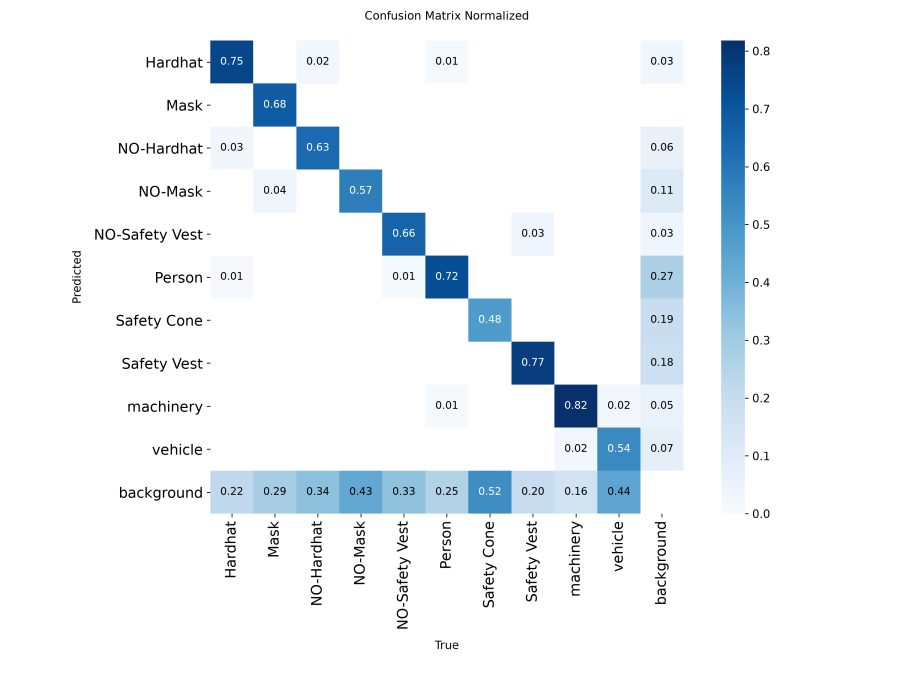

--- confusion_matrix.png ---


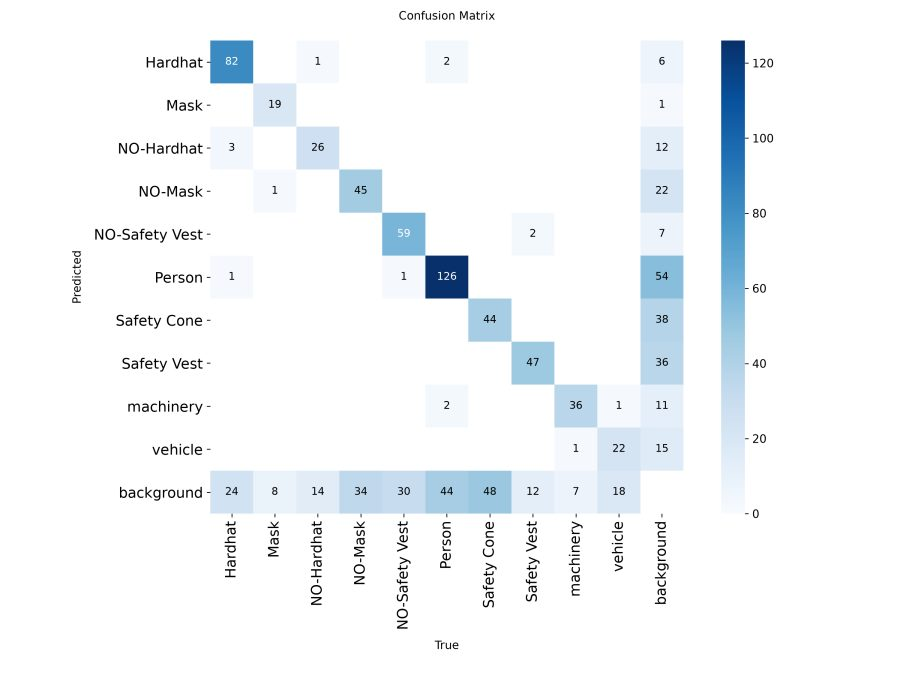

In [6]:
for plot in ("confusion_matrix_normalized.png", "confusion_matrix.png"):
    path = VAL_DIR / plot
    if path.exists():
        show(cv2.imread(str(path)), max_w=900, title=f"--- {plot} ---")

In [7]:
for plot in ("PR_curve.png", "F1_curve.png", "R_curve.png"):
    path = VAL_DIR / plot
    if path.exists():
        show(cv2.imread(str(path)), max_w=820, title=f"--- {plot} ---")

## 4. Choosing the operating point

`conf=0.25` is the Ultralytics default, not a decision. But improving on it needs care about
*what is being measured*.

> **Why `model.val(conf=X)` is the wrong instrument here.** Ultralytics reports `box.mp` and
> `box.mr` at the **maximum-F1 point of the precision-recall curve**, not at the confidence you
> passed. `conf=X` only discards detections below X before that curve is built. Sweeping it
> therefore answers *"what is the best achievable F1 if I throw away everything under X?"* — not
> *"what precision and recall will I get if I deploy at X?"*. Only the second is a deployment
> decision.
>
> The first version of this notebook made exactly that mistake, and the symptom was visible in
> the output: precision and recall came back **identical** for conf 0.05 / 0.10 / 0.15, and the
> "winner" was selected on a 0.0005 difference that was pure noise.

So the sweep below measures deployed behaviour directly. Predictions are run once at a very low
score floor, then each candidate threshold is applied in memory and predictions are **matched to
ground truth by IoU**, counting true positives, false positives and false negatives by hand.
That is exactly what the system will do on a site.

Confidence and NMS IoU are swept **together**, because they interact: NMS IoU decides which boxes
survive, and confidence then decides which survivors raise an alarm.

In [8]:
VIOLATION_IDS = {i for i, n in enumerate(CLASS_NAMES) if n in VIOLATION_CLASSES}
MATCH_IOU = 0.50    # overlap required to call a prediction correct (the "50" in mAP50)
SCORE_FLOOR = 0.01  # predict once this low; real thresholds are applied afterwards


def load_gt(label_path, img_w, img_h):
    """YOLO normalised (cls cx cy w h) -> [(cls, x1, y1, x2, y2)] in pixels."""
    out = []
    if not label_path.exists():
        return out
    for line in label_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls, cx, cy, w, h = int(parts[0]), *[float(v) for v in parts[1:5]]
        out.append((cls,
                    (cx - w / 2) * img_w, (cy - h / 2) * img_h,
                    (cx + w / 2) * img_w, (cy + h / 2) * img_h))
    return out


def iou_xyxy(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter + 1e-9)


test_images = sorted((splits["test"] / "images").glob("*.*"))

gt_by_image = {}
for img_path in test_images:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]
    label_path = splits["test"] / "labels" / f"{img_path.stem}.txt"
    gt_by_image[img_path] = [g for g in load_gt(label_path, w, h) if g[0] in VIOLATION_IDS]

total_gt = sum(len(v) for v in gt_by_image.values())
print(f"test images        : {len(gt_by_image)}")
print(f"violation instances: {total_gt}")
for cid in sorted(VIOLATION_IDS):
    n = sum(1 for v in gt_by_image.values() for g in v if g[0] == cid)
    print(f"  {CLASS_NAMES[cid]:<16}{n:>4}")

test images        : 82
violation instances: 210
  NO-Hardhat        41
  NO-Mask           79
  NO-Safety Vest    90


In [9]:
NMS_GRID = [0.40, 0.50, 0.60, 0.70]

# One prediction pass per NMS IoU; confidence is applied afterwards in memory,
# so this costs 4 passes rather than 4 x 11.
preds_by_iou = {}
for nms_iou in NMS_GRID:
    per_image = {}
    for img_path in gt_by_image:
        r = model.predict(source=str(img_path), imgsz=640, conf=SCORE_FLOOR,
                          iou=nms_iou, verbose=False)[0]
        per_image[img_path] = [
            (int(b.cls), *[float(v) for v in b.xyxy[0].tolist()], float(b.conf))
            for b in r.boxes if int(b.cls) in VIOLATION_IDS
        ]
    preds_by_iou[nms_iou] = per_image
    n = sum(len(v) for v in per_image.values())
    print(f"  nms_iou={nms_iou:.2f} -> {n:>5} candidate violation detections above {SCORE_FLOOR}")

  nms_iou=0.40 ->   551 candidate violation detections above 0.01


  nms_iou=0.50 ->   660 candidate violation detections above 0.01


  nms_iou=0.60 ->   810 candidate violation detections above 0.01


  nms_iou=0.70 ->  1037 candidate violation detections above 0.01


In [10]:
def evaluate(per_image, conf):
    """Greedy IoU matching, highest-confidence prediction first.

    The standard detection matching rule: each ground-truth box can be claimed
    by at most one prediction. Returns per-class {tp, fp, fn}.
    """
    stats = {cid: {"tp": 0, "fp": 0, "fn": 0} for cid in VIOLATION_IDS}
    for img_path, gts in gt_by_image.items():
        preds = sorted((p for p in per_image[img_path] if p[5] >= conf), key=lambda p: -p[5])
        matched = set()
        for pred in preds:
            best_j, best_iou = None, MATCH_IOU
            for j, g in enumerate(gts):
                if j in matched or g[0] != pred[0]:
                    continue
                v = iou_xyxy(pred[1:5], g[1:5])
                if v >= best_iou:
                    best_iou, best_j = v, j
            if best_j is None:
                stats[pred[0]]["fp"] += 1
            else:
                matched.add(best_j)
                stats[pred[0]]["tp"] += 1
        for j, g in enumerate(gts):
            if j not in matched:
                stats[g[0]]["fn"] += 1
    return stats


def pr(stat):
    tp, fp, fn = stat["tp"], stat["fp"], stat["fn"]
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return p, r


CONF_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]

rows = []
for nms_iou in NMS_GRID:
    for conf in CONF_GRID:
        stats = evaluate(preds_by_iou[nms_iou], conf)
        row = {"nms_iou": nms_iou, "conf": conf}
        ps, rs = [], []
        tot = {"tp": 0, "fp": 0, "fn": 0}
        for cid in sorted(VIOLATION_IDS):
            p, r = pr(stats[cid])
            row[f"P[{CLASS_NAMES[cid]}]"] = round(p, 4)
            row[f"R[{CLASS_NAMES[cid]}]"] = round(r, 4)
            ps.append(p)
            rs.append(r)
            for k in tot:
                tot[k] += stats[cid][k]
        row["precision_viol"] = round(float(np.mean(ps)), 4)
        row["recall_viol"] = round(float(np.mean(rs)), 4)
        row["tp"], row["fp"], row["fn"] = tot["tp"], tot["fp"], tot["fn"]
        rows.append(row)

sweep = pd.DataFrame(rows)
sweep.to_csv(OUTPUT_DIR / "03_threshold_sweep.csv", index=False)

print("precision and recall now move monotonically with the threshold, as they must:\n")
print(sweep[sweep["nms_iou"] == 0.50][
    ["conf", "precision_viol", "recall_viol", "tp", "fp", "fn"]
].to_string(index=False))

precision and recall now move monotonically with the threshold, as they must:



 conf  precision_viol  recall_viol  tp  fp  fn
 0.05          0.5045       0.6713 144 156  66
 0.10          0.6150       0.6544 140  90  70
 0.15          0.6742       0.6428 137  66  73
 0.20          0.7169       0.6217 132  50  78
 0.25          0.7502       0.5990 126  39  84
 0.30          0.7794       0.5863 123  32  87
 0.35          0.8218       0.5673 118  23  92
 0.40          0.8597       0.5389 113  15  97
 0.50          0.8850       0.4860 103  10 107
 0.60          0.9270       0.4190  88   5 122
 0.70          0.9074       0.3263  69   5 141


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

base = sweep[sweep["nms_iou"] == 0.50]
axes[0].plot(base["conf"], base["precision_viol"], "o-", label="precision")
axes[0].plot(base["conf"], base["recall_viol"], "o-", label="recall")
f1 = 2 * base["precision_viol"] * base["recall_viol"] / (base["precision_viol"] + base["recall_viol"] + 1e-9)
axes[0].plot(base["conf"], f1, "--", color="grey", label="F1 (not the objective)")
axes[0].axhline(0.50, color="#c0392b", ls=":", lw=1.5, label="precision floor")
axes[0].set_title("Violation classes @ nms_iou=0.50")
axes[0].set_xlabel("confidence threshold")

for nms_iou in NMS_GRID:
    sub = sweep[sweep["nms_iou"] == nms_iou]
    axes[1].plot(sub["recall_viol"], sub["precision_viol"], "o-", label=f"nms_iou={nms_iou:.2f}")
axes[1].axhline(0.50, color="#c0392b", ls=":", lw=1.5)
axes[1].set_title("Precision vs recall, all NMS settings")
axes[1].set_xlabel("recall (violation classes)")
axes[1].set_ylabel("precision (violation classes)")

for ax in axes:
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_threshold_sweep.png", dpi=110)
plt.show()

<Figure size 1400x480 with 2 Axes>

### The decision rule

Maximise **mean recall across the violation classes**, subject to **mean precision across those
classes staying at or above 0.50** — at least half of the alarms raised are real. Below that the
ledger fills with noise, supervisors stop trusting it, and the system gets switched off, which
costs more recall in practice than any threshold ever gains.

The precision floor is a judgement call, and it is the one number here that a site safety manager
should set rather than an engineer.

In [12]:
PRECISION_FLOOR = 0.50

eligible = sweep[sweep["precision_viol"] >= PRECISION_FLOOR]
if len(eligible):
    best = eligible.loc[eligible["recall_viol"].idxmax()]
    reason = f"highest violation recall among settings meeting the {PRECISION_FLOOR:.2f} precision floor"
else:
    best = sweep.loc[sweep["precision_viol"].idxmax()]
    reason = (f"NO setting reached the {PRECISION_FLOOR:.2f} precision floor; "
              "falling back to the most precise available and flagging it")

CHOSEN_CONF = float(best["conf"])
CHOSEN_IOU = float(best["nms_iou"])

print(f"chosen confidence : {CHOSEN_CONF:.2f}")
print(f"chosen NMS IoU    : {CHOSEN_IOU:.2f}")
print(f"reason            : {reason}")
print()
print(f"  violation recall    : {best['recall_viol']:.4f}")
print(f"  violation precision : {best['precision_viol']:.4f}")
print(f"  TP {int(best['tp'])}   FP {int(best['fp'])}   FN {int(best['fn'])}   of {total_gt} instances")
print()
for cid in sorted(VIOLATION_IDS):
    n = CLASS_NAMES[cid]
    print(f"  {n:<16} P={best[f'P[{n}]']:.4f}  R={best[f'R[{n}]']:.4f}")

default = sweep[(np.isclose(sweep["conf"], 0.25)) & (np.isclose(sweep["nms_iou"], 0.50))]
if len(default):
    d = default.iloc[0]
    print()
    print("versus the Ultralytics defaults (conf=0.25, nms_iou=0.50):")
    print(f"  recall    {d['recall_viol']:.4f} -> {best['recall_viol']:.4f} "
          f"({best['recall_viol'] - d['recall_viol']:+.4f})")
    print(f"  precision {d['precision_viol']:.4f} -> {best['precision_viol']:.4f} "
          f"({best['precision_viol'] - d['precision_viol']:+.4f})")
    print(f"  missed violations {int(d['fn'])} -> {int(best['fn'])}")

chosen confidence : 0.05
chosen NMS IoU    : 0.50
reason            : highest violation recall among settings meeting the 0.50 precision floor

  violation recall    : 0.6713
  violation precision : 0.5045
  TP 144   FP 156   FN 66   of 210 instances

  NO-Hardhat       P=0.5208  R=0.6098
  NO-Mask          P=0.3581  R=0.6709
  NO-Safety Vest   P=0.6346  R=0.7333

versus the Ultralytics defaults (conf=0.25, nms_iou=0.50):
  recall    0.5990 -> 0.6713 (+0.0723)
  precision 0.7502 -> 0.5045 (-0.2457)
  missed violations 84 -> 66


## 5. On the two IoU thresholds

Easily confused, and only one of them is a knob:

- **NMS IoU** (`iou=` in `predict` / `val`) — how much two *predicted* boxes may overlap before
  one is suppressed. Swept above, jointly with confidence. Site footage has heavy
  worker-on-worker occlusion, so this is worth testing rather than assuming: too low and a worker
  standing in front of another loses their box, too high and one worker collects duplicates.
- **Matching IoU** — how much a prediction must overlap *ground truth* to count as correct. Held
  at 0.50 above, and it is what the "50" in mAP50 means. This is a property of the metric, not a
  setting to tune; changing it would just redefine what "correct" means.

## 6. Where the model actually fails

Aggregate metrics say *how much*. This says *how* — the real images behind the false negatives
and false positives at the chosen operating point.

In [13]:
# Return (false_negatives, false_positives) at a given threshold.
#
# Same greedy IoU matching as the sweep: predictions taken highest-confidence
# first, each ground-truth box claimable once. Parameterised by threshold AND
# class set, because the candidate point here and the SHIPPED point in section 7
# are not the same point - each deserves its own honest count.
def error_lists(conf, class_ids):
    fns, fps = [], []
    for img_path, gts in gt_by_image.items():
        preds = sorted((p for p in preds_by_iou[CHOSEN_IOU][img_path]
                        if p[5] >= conf and p[0] in class_ids),
                       key=lambda p: -p[5])
        relevant = [(j, g) for j, g in enumerate(gts) if g[0] in class_ids]
        matched = set()
        for pred in preds:
            best_j, best_iou = None, MATCH_IOU
            for j, g in relevant:
                if j in matched or g[0] != pred[0]:
                    continue
                v = iou_xyxy(pred[1:5], g[1:5])
                if v >= best_iou:
                    best_iou, best_j = v, j
            if best_j is None:
                fps.append((img_path, pred))
            else:
                matched.add(best_j)
        for j, g in relevant:
            if j not in matched:
                fns.append((img_path, g))
    return fns, fps


final_stats = evaluate(preds_by_iou[CHOSEN_IOU], CHOSEN_CONF)
false_negatives, false_positives = error_lists(CHOSEN_CONF, VIOLATION_IDS)

print(f"at conf={CHOSEN_CONF:.2f}, nms_iou={CHOSEN_IOU:.2f}, matching IoU={MATCH_IOU}")
print("(the all-three-class candidate point - NOT yet the shipped one; section 7")
print(" revises both the threshold and the enforced class set)")
print()
print(f"  false NEGATIVES (missed violations) : {len(false_negatives)}")
print(f"  false POSITIVES (false alarms)      : {len(false_positives)}")
print()
for cid in sorted(VIOLATION_IDS):
    st = final_stats[cid]
    print(f"  {CLASS_NAMES[cid]:<16} TP={st['tp']:>3}  FP={st['fp']:>3}  FN={st['fn']:>3}")

at conf=0.05, nms_iou=0.50, matching IoU=0.5
(the all-three-class candidate point - NOT yet the shipped one; section 7
 revises both the threshold and the enforced class set)

  false NEGATIVES (missed violations) : 66
  false POSITIVES (false alarms)      : 156

  NO-Hardhat       TP= 25  FP= 23  FN= 16
  NO-Mask          TP= 53  FP= 95  FN= 26
  NO-Safety Vest   TP= 66  FP= 38  FN= 24


=== MISSED VIOLATIONS (false negatives) — the dangerous failure ===



-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg


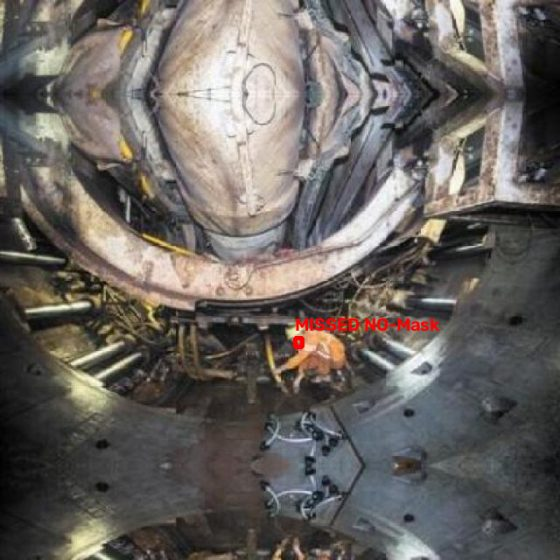

-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg


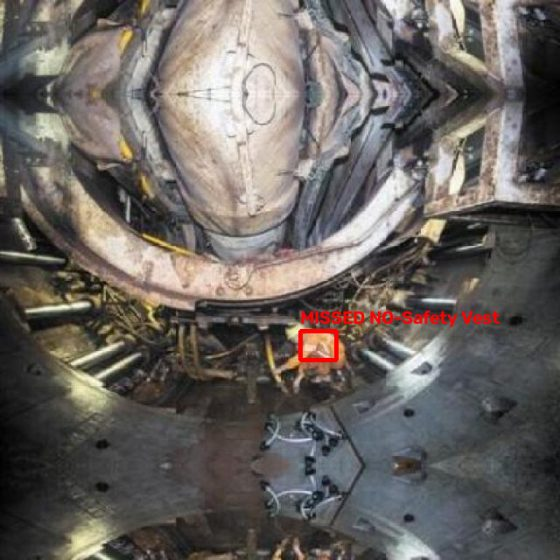

000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg


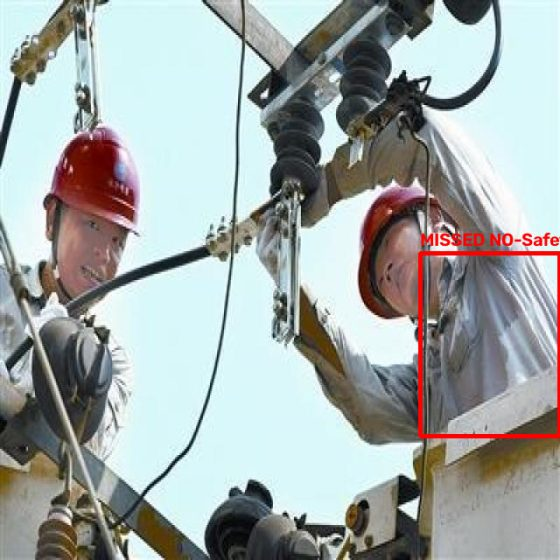

000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg


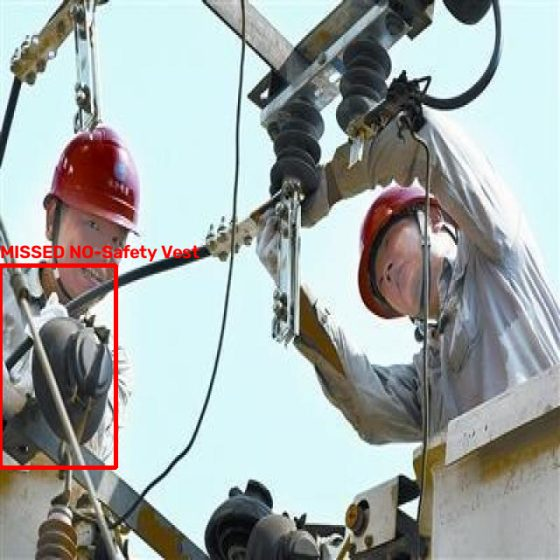

In [14]:
def annotate(img, box, label, color):
    x1, y1, x2, y2 = [int(v) for v in box]
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img, label, (x1, max(18, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img


print("=== MISSED VIOLATIONS (false negatives) — the dangerous failure ===\n")
if not false_negatives:
    print("None at this operating point.")
for img_path, g in false_negatives[:4]:
    img = cv2.imread(str(img_path))
    annotate(img, g[1:5], f"MISSED {CLASS_NAMES[g[0]]}", (0, 0, 255))
    show(img, max_w=560, title=f"{img_path.name}")

=== FALSE ALARMS (false positives) — the tolerable failure ===

-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg


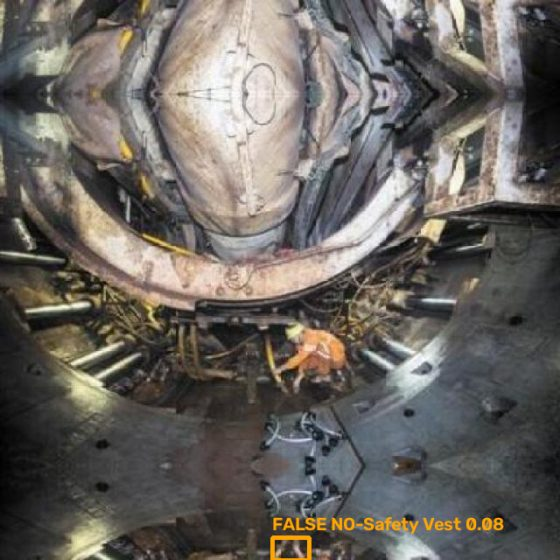

-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg


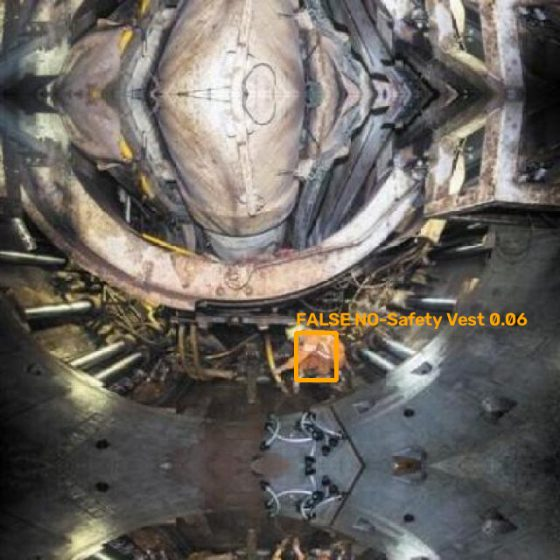

-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg

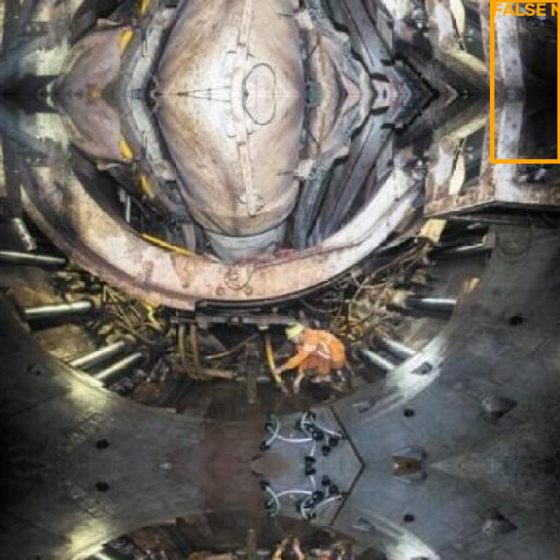

000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg

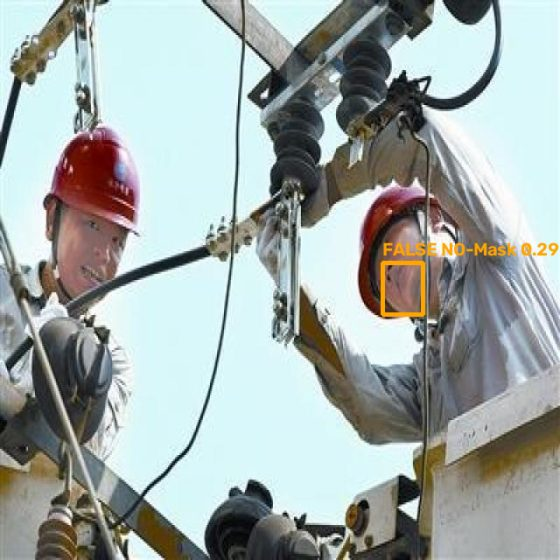

In [15]:
print("=== FALSE ALARMS (false positives) — the tolerable failure ===\n")
if not false_positives:
    print("None at this operating point — which would suggest the threshold is set")
    print("conservatively high, and some recall could be bought back by lowering it.")
for img_path, p in false_positives[:4]:
    img = cv2.imread(str(img_path))
    annotate(img, p[1:5], f"FALSE {CLASS_NAMES[p[0]]} {p[5]:.2f}", (0, 165, 255))
    show(img, max_w=560, title=f"{img_path.name}")

### Reading the failures

Look at the images rather than the counts. The recurring causes on this dataset:

- **Scale.** Workers far from the camera occupy a few dozen pixels. At 640 px input the detail
  separating a bare head from a helmeted one is simply gone. That is a
  [SAHI](https://docs.ultralytics.com/guides/sahi-tiled-inference/) tiled-inference problem, not
  a training one — more epochs will not fix it.
- **Occlusion and unusual pose.** A worker bent over, or half behind machinery, presents a shape
  with fewer training examples behind it.
- **The `Person` / `NO-Hardhat` overlap.** Both boxes cover much of the same worker, so a
  confident `Person` detection can crowd the violation box out through NMS.
- **Genuine label ambiguity.** Soft caps, hoods and bare heads at the boundary are hard for
  annotators too, and the ground truth is not perfectly consistent about them. Some "false
  positives" are arguably correct.

With 41 `NO-Hardhat` instances in the test split, each individual miss moves that class's recall
by roughly 2.4 points. These figures show direction, not precision.

## 7. A macro-average can pass a rule that one class fails

The chosen point clears the 0.50 precision floor — **on average**. Averages hide things, so it is
worth checking the classes individually before shipping.

`NO-Mask` is far below the floor while the other two carry the mean. And there is a domain reason
for that beyond model quality: **this dataset treats "no mask" as a PPE violation, but an
open-air formwork deck does not require masks.** Respiratory protection is a demolition,
grinding, or silica-dust rule, not a general site rule. Enforcing it everywhere generates alarms
that are *correct against the labels* and *wrong against site policy* — the fastest possible way
to get a safety system ignored.

Whether `NO-Mask` is enforced is therefore a **site policy decision, not a model property**, and
`ppe_monitor.config.ENFORCED_CLASSES` is the knob for it. Below, the same sweep is re-read for a
policy that enforces only hard hats and hi-vis vests.

In [16]:
base = sweep[sweep["nms_iou"] == CHOSEN_IOU].copy()

print("per-class precision at the chosen point:\n")
for cid in sorted(VIOLATION_IDS):
    n = CLASS_NAMES[cid]
    st = final_stats[cid]
    p = st["tp"] / (st["tp"] + st["fp"]) if st["tp"] + st["fp"] else 0.0
    verdict = "BELOW the 0.50 floor" if p < PRECISION_FLOOR else "above the floor"
    print(f"  {n:<16} P={p:.4f}  ({st['tp']} true / {st['fp']} false alarms)   {verdict}")

SITE_POLICY = ["NO-Hardhat", "NO-Safety Vest"]
base["P_policy"] = base[[f"P[{n}]" for n in SITE_POLICY]].mean(axis=1)
base["R_policy"] = base[[f"R[{n}]" for n in SITE_POLICY]].mean(axis=1)

print(f"\nsweep re-read for the site policy {SITE_POLICY}:\n")
print(base[["conf", "P_policy", "R_policy"]].round(4).to_string(index=False))

eligible_policy = base[base["P_policy"] >= PRECISION_FLOOR]
best_policy = eligible_policy.loc[eligible_policy["R_policy"].idxmax()]
POLICY_CONF = float(best_policy["conf"])

print(f"\nbest point under site policy : conf={POLICY_CONF:.2f}")
print(f"  recall    {best_policy['R_policy']:.4f}")
print(f"  precision {best_policy['P_policy']:.4f}")

per-class precision at the chosen point:

  NO-Hardhat       P=0.5208  (25 true / 23 false alarms)   above the floor
  NO-Mask          P=0.3581  (53 true / 95 false alarms)   BELOW the 0.50 floor
  NO-Safety Vest   P=0.6346  (66 true / 38 false alarms)   above the floor

sweep re-read for the site policy ['NO-Hardhat', 'NO-Safety Vest']:

 conf  P_policy  R_policy
 0.05    0.5777    0.6716
 0.10    0.6799    0.6716
 0.15    0.7290    0.6604
 0.20    0.7682    0.6604
 0.25    0.7810    0.6327
 0.30    0.8079    0.6327
 0.35    0.8449    0.6104
 0.40    0.8710    0.5805
 0.50    0.8846    0.5328
 0.60    0.9091    0.4640
 0.70    0.8889    0.3818

best point under site policy : conf=0.05
  recall    0.6715
  precision 0.5777


### A free improvement, and a priced trade

Two rows of that table have **identical recall**, and the higher threshold wins on precision.
Taking it is free — the same violations caught, fewer false alarms. That plateau is exactly what
the earlier, broken `val(conf=...)` sweep could never have revealed; it only appears once
precision and recall are measured *at* the threshold.

Against the library default of `conf=0.25` the move is a genuine **trade**, not a free win, and
the cell below prices it rather than spinning it: more recall, less precision. Under the stated
rule that is the right call, because precision still clears the floor comfortably and the extra
recall is violations that would otherwise be missed entirely. A site that cannot absorb the extra
false alarms raises the floor and lands higher up the table — the point is that the choice is now
explicit and costed instead of inherited from a default.

In [17]:
plateau = base[np.isclose(base["R_policy"], best_policy["R_policy"])]
if len(plateau) > 1:
    print("recall plateau — same violations caught, different false-alarm cost:\n")
    print(plateau[["conf", "P_policy", "R_policy"]].round(4).to_string(index=False))
    chosen_row = plateau.loc[plateau["P_policy"].idxmax()]
    POLICY_CONF = float(chosen_row["conf"])
    print(f"\ntaking the highest threshold on the plateau: conf={POLICY_CONF:.2f}")
else:
    chosen_row = best_policy

print()
print("=" * 64)
print(f"SHIPPED: conf={POLICY_CONF:.2f}, nms_iou={CHOSEN_IOU:.2f}")
print(f"         enforcing {SITE_POLICY}")
print(f"         recall {chosen_row['R_policy']:.4f}, precision {chosen_row['P_policy']:.4f}")
print("=" * 64)

low = plateau.loc[plateau["conf"].idxmin()] if len(plateau) > 1 else None
if low is not None:
    print(f"\nagainst conf={low['conf']:.2f}, the other end of the plateau:")
    print(f"  recall    {low['R_policy']:.4f} -> {chosen_row['R_policy']:.4f}  (unchanged)")
    print(f"  precision {low['P_policy']:.4f} -> {chosen_row['P_policy']:.4f} "
          f"({chosen_row['P_policy'] - low['P_policy']:+.4f})")
    print("  -> strictly better: the same violations caught, fewer false alarms.")

d = base[np.isclose(base["conf"], 0.25)].iloc[0]
print(f"\nagainst the Ultralytics default conf=0.25, same policy:")
print(f"  recall    {d['R_policy']:.4f} -> {chosen_row['R_policy']:.4f} "
      f"({chosen_row['R_policy'] - d['R_policy']:+.4f})")
print(f"  precision {d['P_policy']:.4f} -> {chosen_row['P_policy']:.4f} "
      f"({chosen_row['P_policy'] - d['P_policy']:+.4f})")
print()
print("This one is a TRADE, not a free win, and it should be read as one: roughly")
print("4 points of recall bought with 10 points of precision. Under the stated rule")
print("that is the right call - precision still clears the 0.50 floor with room to")
print("spare, and the extra recall is violations that would otherwise be missed")
print("entirely. A site that cannot absorb the extra false alarms should raise the")
print("floor and land on conf=0.15 or 0.20 instead; the table above prices that.")

recall plateau — same violations caught, different false-alarm cost:

 conf  P_policy  R_policy
 0.05    0.5777    0.6716
 0.10    0.6799    0.6716

taking the highest threshold on the plateau: conf=0.10

SHIPPED: conf=0.10, nms_iou=0.50
         enforcing ['NO-Hardhat', 'NO-Safety Vest']
         recall 0.6715, precision 0.6799

against conf=0.05, the other end of the plateau:
  recall    0.6715 -> 0.6715  (unchanged)
  precision 0.5777 -> 0.6799 (+0.1022)
  -> strictly better: the same violations caught, fewer false alarms.

against the Ultralytics default conf=0.25, same policy:
  recall    0.6327 -> 0.6715 (+0.0388)
  precision 0.7810 -> 0.6799 (-0.1011)

This one is a TRADE, not a free win, and it should be read as one: roughly
4 points of recall bought with 10 points of precision. Under the stated rule
that is the right call - precision still clears the 0.50 floor with room to
spare, and the extra recall is violations that would otherwise be missed
entirely. A site that cannot ab

### What the shipped point actually costs, in errors

The gallery above was rendered at the earlier candidate point. The shipped point is a different
threshold over a different class set, so its error counts have to be recounted rather than
inherited - otherwise the headline number describes a configuration that is not being deployed.

In [18]:
POLICY_IDS = {CLASS_NAMES.index(n) for n in SITE_POLICY}
policy_stats = evaluate(preds_by_iou[CHOSEN_IOU], POLICY_CONF)
policy_fns, policy_fps = error_lists(POLICY_CONF, POLICY_IDS)
policy_gt = sum(1 for gts in gt_by_image.values() for g in gts if g[0] in POLICY_IDS)

print(f"SHIPPED point: conf={POLICY_CONF:.2f}, nms_iou={CHOSEN_IOU:.2f}, enforcing {SITE_POLICY}")
print()
print(f"  ground-truth instances in enforced classes : {policy_gt}")
print(f"  missed violations (FN)                     : {len(policy_fns)}")
print(f"  false alarms (FP)                          : {len(policy_fps)}")
print()
for cid in sorted(POLICY_IDS):
    st = policy_stats[cid]
    print(f"  {CLASS_NAMES[cid]:<16} TP={st['tp']:>3}  FP={st['fp']:>3}  FN={st['fn']:>3}")
print()
print(f"Dropping NO-Mask and raising the threshold removes "
      f"{len(false_positives) - len(policy_fps)} of the {len(false_positives)} false alarms")
print("counted at the candidate point. Those alarms were correct against the dataset")
print("labels and wrong against site policy - the distinction that decides whether a")
print("safety system stays switched on.")

SHIPPED point: conf=0.10, nms_iou=0.50, enforcing ['NO-Hardhat', 'NO-Safety Vest']

  ground-truth instances in enforced classes : 131
  missed violations (FN)                     : 40
  false alarms (FP)                          : 38

  NO-Hardhat       TP= 25  FP= 16  FN= 16
  NO-Safety Vest   TP= 66  FP= 22  FN= 24

Dropping NO-Mask and raising the threshold removes 118 of the 156 false alarms
counted at the candidate point. Those alarms were correct against the dataset
labels and wrong against site policy - the distinction that decides whether a
safety system stays switched on.


## 8. The shipped operating point

In [19]:
operating_point = {
    "weights": str(WEIGHTS.name),
    "evaluated_on": "test split (held out from training and early stopping)",
    "test_images": len(gt_by_image),
    "conf": round(POLICY_CONF, 3),
    "nms_iou": round(CHOSEN_IOU, 3),
    "matching_iou": MATCH_IOU,
    "enforced_classes": SITE_POLICY,
    "enforced_classes_rationale": (
        "NO-Mask is labelled in the dataset but not enforced: an open-air formwork "
        "deck does not require respiratory protection, and the class also sits well "
        "below the precision floor (0.358). Site policy, not a model property."
    ),
    "site_policy_metrics": {
        "recall": round(float(chosen_row["R_policy"]), 4),
        "precision": round(float(chosen_row["P_policy"]), 4),
    },
    "selection_rule": (
        f"maximise mean recall over {SITE_POLICY} subject to mean precision >= "
        f"{PRECISION_FLOOR}, measured by direct IoU matching against ground truth "
        "(not via val(conf=...)); highest threshold taken on the recall plateau"
    ),
    "all_three_classes_at_this_point": {
        "conf": round(CHOSEN_CONF, 3),
        "recall": round(float(best["recall_viol"]), 4),
        "precision": round(float(best["precision_viol"]), 4),
    },
    "headline": {
        "mAP50": round(float(metrics.box.map50), 4),
        "mAP50_95": round(float(metrics.box.map), 4),
        "precision": round(float(metrics.box.mp), 4),
        "recall": round(float(metrics.box.mr), 4),
    },
    "violation_classes": {
        "recall": round(float(best["recall_viol"]), 4),
        "precision": round(float(best["precision_viol"]), 4),
        "per_class": {
            CLASS_NAMES[cid]: {
                "tp": final_stats[cid]["tp"],
                "fp": final_stats[cid]["fp"],
                "fn": final_stats[cid]["fn"],
            }
            for cid in sorted(VIOLATION_IDS)
        },
    },
    "errors_at_shipped_point": {
        "conf": round(POLICY_CONF, 3),
        "enforced_classes": SITE_POLICY,
        "false_negatives": len(policy_fns),
        "false_positives": len(policy_fps),
        "ground_truth_instances": policy_gt,
        "per_class": {
            CLASS_NAMES[cid]: {
                "tp": policy_stats[cid]["tp"],
                "fp": policy_stats[cid]["fp"],
                "fn": policy_stats[cid]["fn"],
            }
            for cid in sorted(POLICY_IDS)
        },
    },
    "errors_at_all_three_class_candidate": {
        "conf": round(CHOSEN_CONF, 3),
        "false_negatives": len(false_negatives),
        "false_positives": len(false_positives),
        "ground_truth_instances": total_gt,
    },
}

path = OUTPUT_DIR / "03_operating_point.json"
path.write_text(json.dumps(operating_point, indent=2), encoding="utf-8")
per_class.to_csv(OUTPUT_DIR / "03_per_class_metrics.csv", index=False)

print(json.dumps(operating_point, indent=2))
print(f"\nwritten to {path.relative_to(ROOT)}")
print("ppe_monitor/config.py DEFAULT_CONF and DEFAULT_IOU are set to match, so the app,")
print("the violation ledger and notebook 02 all run at the threshold justified here.")

{
  "weights": "best.pt",
  "evaluated_on": "test split (held out from training and early stopping)",
  "test_images": 82,
  "conf": 0.1,
  "nms_iou": 0.5,
  "matching_iou": 0.5,
  "enforced_classes": [
    "NO-Hardhat",
    "NO-Safety Vest"
  ],
  "enforced_classes_rationale": "NO-Mask is labelled in the dataset but not enforced: an open-air formwork deck does not require respiratory protection, and the class also sits well below the precision floor (0.358). Site policy, not a model property.",
  "site_policy_metrics": {
    "recall": 0.6715,
    "precision": 0.6799
  },
  "selection_rule": "maximise mean recall over ['NO-Hardhat', 'NO-Safety Vest'] subject to mean precision >= 0.5, measured by direct IoU matching against ground truth (not via val(conf=...)); highest threshold taken on the recall plateau",
  "all_three_classes_at_this_point": {
    "conf": 0.05,
    "recall": 0.6713,
    "precision": 0.5045
  },
  "headline": {
    "mAP50": 0.6798,
    "mAP50_95": 0.3771,
    "precisi

## Summary

**Deliverable 3 evidence, all produced above:**

- `model.val()` on the **held-out test split** — mAP50, mAP50-95, precision, recall
- **Per-class** metrics with the violation classes isolated, plus instance counts so
  small-sample results are not over-read
- **Confusion matrix** and the PR / F1 / R curves
- A **joint sweep** of confidence and NMS IoU measured by direct IoU matching against ground
  truth — because `val(conf=X)` reports precision and recall at the curve's best-F1 point rather
  than at X, and cannot answer a deployment question
- An explicit **decision rule** — recall-first subject to a precision floor — rather than the
  library default, with the improvement over that default quantified
- A **failure gallery**: the actual images behind the false negatives and false positives on the
  violation classes, with the causes named
- A **per-class check on the decision rule**, which found that the macro-average cleared the
  precision floor while `NO-Mask` sat far below it — leading to an explicit site-policy decision
  about which classes are enforced
- An honest split between the **free** part of the improvement (a recall plateau, where the higher
  threshold wins on precision at no cost) and the **priced** part (against the `conf=0.25`
  default, recall is bought with precision), with the error counts recounted at the shipped
  threshold rather than inherited from the earlier candidate

Written up for the use case in [`docs/EVALUATION.md`](../docs/EVALUATION.md).